# Uses 'tictactoe_moves_1.csv', 'tictactoe_moves_2.csv', and 'TicTacToe.csv' data

In [2]:
import random
import csv
from datetime import datetime
timestamp = str(int(datetime.timestamp(datetime.now())))
f = open('tictactoe_moves_' + timestamp + '.csv', 'w')
wr = csv.writer(f)

board = [' ' for x in range(10)]

def insertLetter(letter,pos):
    board[pos] = letter

def spaceIsFree(pos):
    return board[pos] == ' '

def printBoard(board):
    print('   |   |   ')
    print(' ' + board[1] + ' | ' + board[2] + ' | ' + board[3])
    print('   |   |   ')
    print('------------')
    print('   |   |   ')
    print(' ' + board[4] + ' | ' + board[5] + ' | ' + board[6])
    print('   |   |   ')
    print('------------')
    print('   |   |   ')
    print(' ' + board[7] + ' | ' + board[8] + ' | ' + board[9])
    print('   |   |   ')

def isBoardFull(board):
    if board.count(' ') > 1:
        return False
    else:
        return True

def IsBoardEmpty(board):
    if board.count(' ') == len(board):
        return True
    else:
        return False

def IsWinner(b,l):
    return ((b[1] == l and b[2] == l and b[3] == l) or
    (b[4] == l and b[5] == l and b[6] == l) or
    (b[7] == l and b[8] == l and b[9] == l) or
    (b[1] == l and b[4] == l and b[7] == l) or
    (b[2] == l and b[5] == l and b[8] == l) or
    (b[3] == l and b[6] == l and b[9] == l) or
    (b[1] == l and b[5] == l and b[9] == l) or
    (b[3] == l and b[5] == l and b[7] == l))

def playerMove():
    run = True
    while run:
        move = input("please select a position to enter the X between 1 to 9\n")
        try:
            move = int(move)
            if move > 0 and move < 10:
                if spaceIsFree(move):
                    run = False
                    insertLetter('X' , move)
                else:
                    print('Sorry, this space is occupied')
            else:
                print('please type a number between 1 and 9')

        except:
            print('Please type a number between 1 and 9')

    return move

def computerMove():
    possibleMoves = [x for x , letter in enumerate(board) if letter == ' ' and x != 0  ]
    move = 0

    for let in ['O' , 'X']:
        for i in possibleMoves:
            boardcopy = board[:]
            boardcopy[i] = let
            if IsWinner(boardcopy, let):
                move = i
                return move

    cornersOpen = []
    for i in possibleMoves:
        if i in [1 , 3 , 7 , 9]:
            cornersOpen.append(i)

    if len(cornersOpen) > 0:
        move = selectRandom(cornersOpen)
        return move

    if 5 in possibleMoves:
        move = 5
        return move

    edgesOpen = []
    for i in possibleMoves:
        if i in [2,4,6,8]:
            edgesOpen.append(i)

    if len(edgesOpen) > 0:
        move = selectRandom(edgesOpen)
        return move

def selectRandom(li):
    import random
    ln = len(li)
    r = random.randrange(0,ln)
    return li[r]

def main():
    moves_arr = list()
    print("Welcome to the game!")
    printBoard(board)

    while not(isBoardFull(board)):

        if IsBoardEmpty(board):    
            #select first player at random
            if random.choice(['X', 'O']) == 'O':
                move = computerMove()
                moves_arr.append('O'+str(move))
                if move == 0:
                    print(" ")
                else:
                    insertLetter('O' , move)
                    print('computer placed an O at' , move , ':')
                    printBoard(board)


        if not(IsWinner(board , 'O')):
            player_move = playerMove()
            moves_arr.append('X'+str(player_move))
            printBoard(board)
            if isBoardFull(board):
                break
        else:
            print("Computer Wins, you lose!")
            break

        if not(IsWinner(board , 'X')):
            move = computerMove()
            moves_arr.append('O'+str(move))
            if move == 0:
                print(" ")
            else:
                insertLetter('O' , move)
                print('computer placed an o on position' , move , ':')
                printBoard(board)
        else:
            print("You win!")
            break

    if (isBoardFull(board) and (not IsWinner(board, 'O')) \
            and (not IsWinner(board, 'X'))):
        print("Tie game")

    if IsWinner(board, 'O'):
        moves_arr.append(str(-1))
    elif IsWinner(board, 'X'):
        moves_arr.append(str(1))
    else: #tie
        moves_arr.append(str(0))

    return moves_arr

while True:
    x = input("Do you want to play? (y/n)\n")
    if x.lower() == 'y':
        board = [' ' for x in range(10)]
        print('--------------------')
        moves_arr = main()
        print(moves_arr)
        wr.writerow(moves_arr)
        
    else:
        break

f.close()

Do you want to play? (y/n)
 n


In [150]:
import pandas as pd
import numpy as np
import plotly.express as px

data1 = pd.read_csv("tictactoe_moves_1.csv", header=None)
data2 = pd.read_csv("tictactoe_moves_2.csv", header=None)

data1.fillna('', inplace=True)
data2.fillna('', inplace=True)

#data1 = data1.dropna()
#data2 = data2.dropna()

data3 = pd.concat([data1, data2])
data3

,0,1,2,3,4,5,6,7,8,9
0,X5,O7,X1,O9,X8,O2,X3,O6,X4,0.0
1,X1,O7,X5,O9,X8,O2,X3,O6,X4,0.0
2,X4,O7,X3,O1,X9,O6,X5,O2,X8,0.0
3,X5,O7,X3,O9,X8,O2,X1,O4,X6,0.0
4,X6,O7,X1,O9,X8,O3,X5,O2,X4,1.0
5,X1,O9,X7,O4,X3,O2,X5,1,,
6,X1,O7,X3,O2,X9,O5,X6,1,,
0,X5,O9,X1,O7,X8,O2,X3,O4,X6,0.0
1,X1,O7,X3,O2,X9,O5,X6,1,,
2,O9,X1,O3,X6,O7,X8,O5,-1,,


In [153]:
data = data3.values.tolist()
for row in data:
    for x in row:
        x = str(x)
        if "O" in x:
            row.remove(x)

for row2 in data:
    while("" in row2) :
        row2.remove("")
        
data

[['X5', 'X1', 'X8', 'X3', 'X4', 0.0],
 ['X1', 'X5', 'X8', 'X3', 'X4', 0.0],
 ['X4', 'X3', 'X9', 'X5', 'X8', 0.0],
 ['X5', 'X3', 'X8', 'X1', 'X6', 0.0],
 ['X6', 'X1', 'X8', 'X5', 'X4', 1.0],
 ['X1', 'X7', 'X3', 'X5', '1'],
 ['X1', 'X3', 'X9', 'X6', '1'],
 ['X5', 'X1', 'X8', 'X3', 'X6', 0.0],
 ['X1', 'X3', 'X9', 'X6', '1'],
 ['X1', 'X6', 'X8', '-1'],
 ['X2', 'X5', 'X7', 'X6', 0.0],
 ['X4', 'X3', 'X6', 'X9', '1'],
 ['X5', 'X3', '-1'],
 ['X1', 'X5', 'X4', '-1'],
 ['X5', 'X1', 'X2', '-1'],
 ['X3', 'X2', '-1']]

In [154]:
import csv

extra = "X0"
header = ['Outcome', 'Decision1', 'Decision2', 'Decision3', 'Decision4', 'Decision5']
final = []
for row in data: 
    while len(row) < 6:
        row.insert(-1, extra)
    
    final.append([row[-1], int(row[0][1]), int(row[1][1]), int(row[2][1]), int(row[3][1]), int(row[4][1])])

with open('TicTacToe.csv', 'w', encoding='UTF8', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(final)

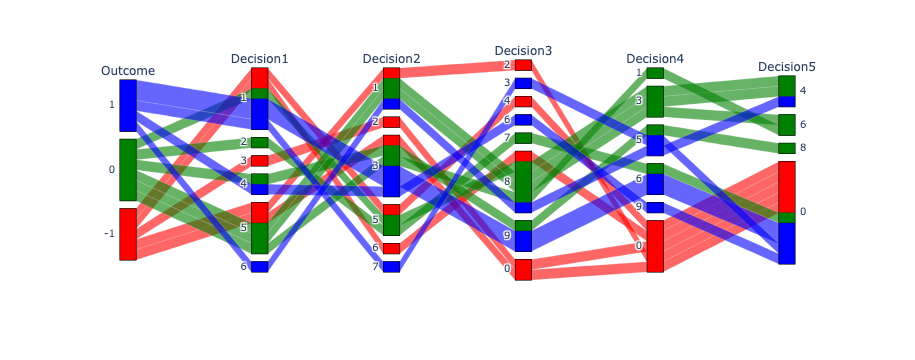

In [9]:
import pandas as pd
import numpy as np
import plotly.express as px

data = pd.read_csv("TicTacToe.csv")
fig = px.parallel_categories(data, color = "Outcome", color_continuous_scale=["red", "green", "blue"])
fig.update_coloraxes(showscale=False)
fig.show()